# Tree Ensembles for Biotech: Random Forests and Gradient Boosting

## Real-World Scenario: Predicting Cancer Cell Line Drug Sensitivity

You have a panel of cancer cell lines profiled with **gene expression** and **mutation status**, plus their **tissue of origin**. You want a model that predicts whether a given cell line will be **sensitive** to a targeted therapy. This is the canonical multi-omics prediction task that drives preclinical drug discovery.

Why tree-based methods dominate this kind of problem in biotech:

- **No feature scaling required** — expression values in TPM, binary mutations, one-hot tissue indicators all live together happily.
- **Automatic interaction detection** — tree splits naturally capture things like *"EGFR high AND KRAS wild-type"*.
- **Robust to noise features** — irrelevant genes simply never get selected as split variables.
- **Interpretable** via feature importance and partial dependence plots.
- **Missing values** can be handled natively (XGBoost/LightGBM/HistGradientBoosting).
- **Outperforms linear models and neural nets on small-to-medium tabular data** — the regime most biotech labs operate in (N in the hundreds to low thousands).

This notebook is a practical tour of what you need to **use these tools in day-to-day biotech work**. It covers:

1. A single decision tree — intuition and why it's not enough
2. **Random Forests** — the reliable workhorse (bagging + feature subsampling)
3. **Out-of-bag error** — free validation when data is precious
4. **Feature importance** — impurity-based vs. permutation, and the correlated-feature trap
5. **Gradient Boosting** — usually the best accuracy on tabular data
6. **Hyperparameter tuning** — the handful of knobs that actually matter
7. **Partial dependence plots** — seeing what the model learned
8. **Practical cheat sheet** — RF vs. GBDT vs. linear, and common pitfalls

The math behind these methods is covered in PML Ch. 18; here we focus on applying them well.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    BaggingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

rng = np.random.default_rng(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## 1. Simulate a Multi-Omics Drug Sensitivity Dataset

We simulate $N=500$ cancer cell lines with three kinds of features typical of pharmacogenomics panels like **GDSC** or **CCLE**:

- **Gene expression** (10 cancer-related genes + 5 noise genes) — continuous, roughly standard-normal.
- **Mutation status** (5 oncogenes) — binary 0/1 with realistic prevalence.
- **Tissue of origin** — categorical (lung, breast, colon, skin), one-hot encoded.

The **true biology** we bake in (to have ground truth to check against):

1. Drug is a targeted therapy hitting the EGFR pathway — **high EGFR expression** → more sensitive.
2. But a **KRAS mutation** activates a bypass pathway → resistance, canceling EGFR dependence.
3. An **EGFR-activating mutation** makes the cell strongly addicted → very sensitive.
4. **Synthetic lethal interaction**: high BCL2 matters *only* when TP53 is wild-type.
5. **Tissue context**: lung cell lines are somewhat more sensitive overall.
6. The other genes and mutations are pure noise — the model has to learn to ignore them.

This is classic tree-model territory: threshold effects, interactions, tissue context, and plenty of irrelevant features to filter out.

In [2]:
N = 500

# Gene expression: 10 real + 5 noise genes
gene_names = ['EGFR', 'KRAS_expr', 'TP53_expr', 'MYC', 'BRCA1',
              'BCL2', 'CDK4', 'MDM2', 'PTEN', 'RB1',
              'NOISE_1', 'NOISE_2', 'NOISE_3', 'NOISE_4', 'NOISE_5']
X_expr = rng.standard_normal((N, len(gene_names)))

# Mutation status (binary) — prevalences loosely based on TCGA pan-cancer
mut_names = ['TP53_mut', 'KRAS_mut', 'EGFR_mut', 'BRAF_mut', 'PIK3CA_mut']
mut_probs = [0.35, 0.25, 0.15, 0.12, 0.20]
X_mut = np.column_stack([rng.binomial(1, p, N) for p in mut_probs])

# Tissue of origin — one-hot
tissues = ['lung', 'breast', 'colon', 'skin']
tissue_idx = rng.integers(0, 4, N)
X_tissue = np.eye(4)[tissue_idx]

# Concatenate into the design matrix
X = np.column_stack([X_expr, X_mut, X_tissue])
feature_names = gene_names + mut_names + [f'tissue_{t}' for t in tissues]
D = X.shape[1]

# --- True biology ---
EGFR   = X_expr[:, 0]
BCL2   = X_expr[:, 5]
TP53_mut = X_mut[:, 0]
KRAS_mut = X_mut[:, 1]
EGFR_mut = X_mut[:, 2]
is_lung  = X_tissue[:, 0]

# Log-odds of being drug-sensitive
logit = (
    1.4 * np.clip(EGFR, -2, 2) * (1 - KRAS_mut)   # EGFR effect, killed by KRAS mut
    + 2.8 * EGFR_mut                               # EGFR mut → strongly sensitive
    + 1.3 * BCL2 * (1 - TP53_mut)                  # synthetic lethal interaction
    + 0.6 * is_lung                                # tissue effect
    - 0.4
)
p_sens = 1 / (1 + np.exp(-logit))
y = rng.binomial(1, p_sens).astype(int)

print(f'N cell lines:         {N}')
print(f'N features:           {D}  ({len(gene_names)} expr + {len(mut_names)} mut + {len(tissues)} tissue)')
print(f'Sensitive fraction:   {y.mean():.2%}')
print(f'Tissue distribution:  ' + ', '.join(f'{t}={np.sum(tissue_idx==i)}' for i, t in enumerate(tissues)))

# Train/test split — stratified so class balance is preserved
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)
print(f'\nTrain: {len(y_train)}   Test: {len(y_test)}')

N cell lines:         500
N features:           24  (15 expr + 5 mut + 4 tissue)
Sensitive fraction:   50.00%
Tissue distribution:  lung=125, breast=124, colon=131, skin=120

Train: 375   Test: 125


In [23]:
X_mut
# X_tissue
# np.eye(4)[1]
# y

array([[1, 0, 0, 0, 1],
       [0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0],
       [1, 0, 1, 0, 0],
       [0, 1, 0, 0, 0]])

## 2. A Single Decision Tree — Build Intuition First

A decision tree learns a sequence of axis-aligned splits. Each internal node asks one question like *"is EGFR expression > 0.8?"* and routes the sample left or right. Leaves contain the predicted class (or probability).

**Fitting** is greedy: at each node we scan all features $j$ and all thresholds $t$, and pick the split that maximizes purity of the children (PML Eq. 18.5). For classification we minimize the **Gini index** (Eq. 18.8) or entropy (Eq. 18.9):

$$G_i = \sum_{c=1}^C \hat\pi_{ic}(1 - \hat\pi_{ic})$$

Let's fit a shallow tree (depth 3) so we can literally read it.

Depth-3 tree test accuracy: 0.584


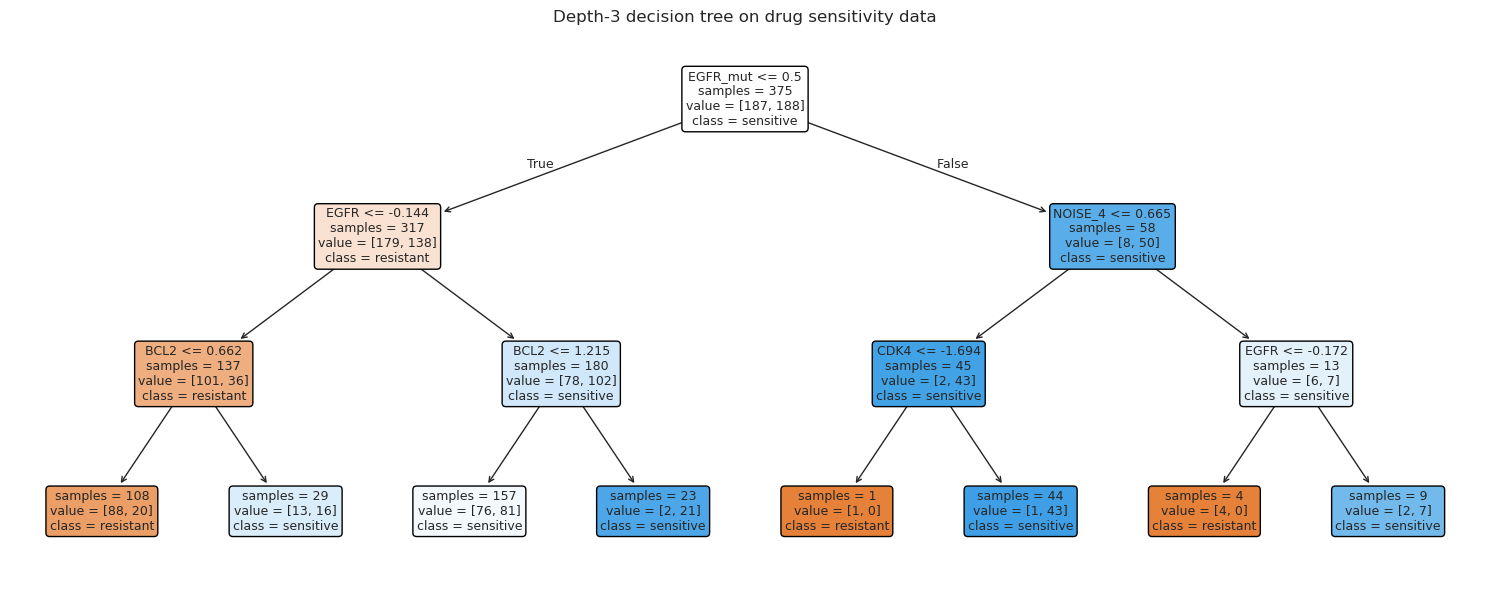

In [3]:
tree_small = DecisionTreeClassifier(max_depth=3, random_state=0)
tree_small.fit(X_train, y_train)

test_acc = accuracy_score(y_test, tree_small.predict(X_test))
print(f'Depth-3 tree test accuracy: {test_acc:.3f}')

fig, ax = plt.subplots(figsize=(15, 6))
plot_tree(
    tree_small,
    feature_names=feature_names,
    class_names=['resistant', 'sensitive'],
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=9,
    ax=ax,
)
ax.set_title('Depth-3 decision tree on drug sensitivity data', fontsize=12)
plt.tight_layout()
plt.show()

**Read it top-down.** At each node the tree picked one feature and one threshold. Notice how the splits often land on the genes/mutations we baked into the true biology — EGFR expression, EGFR mutation, KRAS mutation. That's automatic variable selection at work.

### The depth knob — underfit vs. overfit

Deep trees drive training error to zero by carving the input space into tiny leaves. That almost always overfits. This is the classic bias-variance tradeoff: the single most important hyperparameter for a CART tree is `max_depth` (or equivalently `min_samples_leaf`).

 depth  n_leaves  train_acc  test_acc
     1         2   0.610667     0.592
     2         4   0.674667     0.632
     3         8   0.696000     0.584
     5        23   0.797333     0.512
     8        46   0.941333     0.488
    12        66   0.997333     0.480
    20        67   1.000000     0.488
    13        67   1.000000     0.488


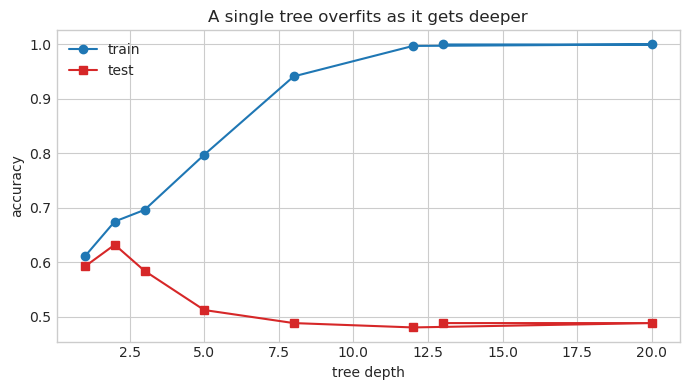

In [4]:
depths = [1, 2, 3, 5, 8, 12, 20, None]  # None = unlimited
rows = []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X_train, y_train)
    rows.append((
        d if d is not None else t.get_depth(),
        t.get_n_leaves(),
        accuracy_score(y_train, t.predict(X_train)),
        accuracy_score(y_test,  t.predict(X_test)),
    ))

df_depth = pd.DataFrame(rows, columns=['depth', 'n_leaves', 'train_acc', 'test_acc'])
print(df_depth.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_depth['depth'], df_depth['train_acc'], 'o-', label='train', color='#1f77b4')
ax.plot(df_depth['depth'], df_depth['test_acc'],  's-', label='test',  color='#d62728')
ax.set_xlabel('tree depth')
ax.set_ylabel('accuracy')
ax.set_title('A single tree overfits as it gets deeper')
ax.legend()
plt.tight_layout()
plt.show()

Training accuracy climbs to ~1.0 while test accuracy peaks at moderate depth and then degrades — textbook overfitting.

### The other big problem: trees are *unstable*

Swap out just a few training points and the tree structure can change completely. This is because splits at the top of the tree cascade into every descendant. PML Fig. 18.3 shows the same effect on the iris dataset. Let's reproduce it on our data.

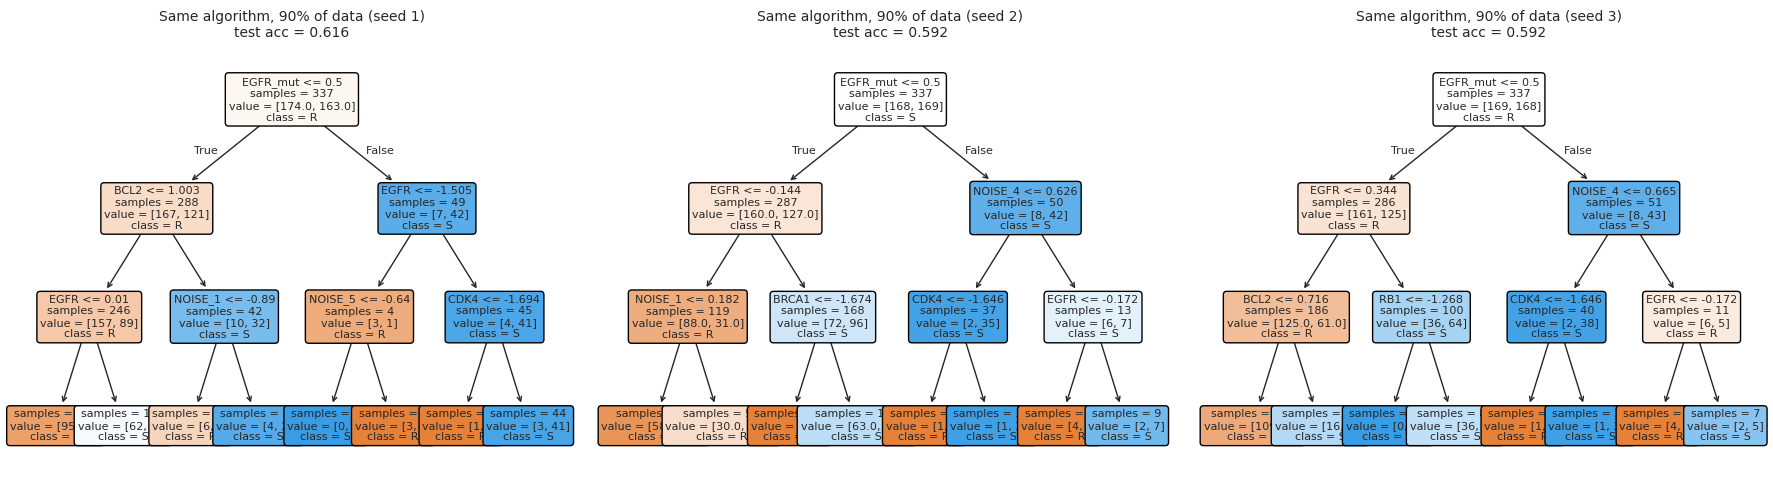

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, seed in zip(axes, [1, 2, 3]):
    # Drop a random 10% of training data
    sub = rng.choice(len(X_train), size=int(0.9 * len(X_train)), replace=False)
    t = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train[sub], y_train[sub])
    plot_tree(t, feature_names=feature_names,
              class_names=['R', 'S'], filled=True, rounded=True,
              impurity=False, fontsize=8, ax=ax)
    ax.set_title(f'Same algorithm, 90% of data (seed {seed})\n'
                 f'test acc = {accuracy_score(y_test, t.predict(X_test)):.3f}',
                 fontsize=10)
plt.tight_layout()
plt.show()

Three nearly-identical training sets → three visibly different trees. **This instability is the crack ensembles pry open.** If individual trees are high-variance estimators, averaging many of them trained on slightly different data drives the variance down without much bias cost.

## 3. Bagging: Average Many Trees to Kill the Variance

**Bagging** (bootstrap aggregating, PML §18.3) is the simplest ensemble:

1. Sample $M$ bootstrap replicates of the training set (same size, *with replacement*).
2. Fit a deep tree on each replicate.
3. Predict by averaging (regression) or majority vote (classification) — Eq. 18.10:

$$f(y | \mathbf{x}) = \frac{1}{|\mathcal{M}|} \sum_{m \in \mathcal{M}} f_m(y | \mathbf{x})$$

Each bootstrap sample contains ~63% of unique training points (since $(1 - 1/N)^N \to e^{-1} \approx 0.37$), so each tree sees a different slice and makes different mistakes. Averaging cancels the uncorrelated errors.

In [6]:
# Single deep (overfitted) tree vs. bag of 50 deep trees
tree_deep = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=0),
    n_estimators=50, bootstrap=True, random_state=0,
).fit(X_train, y_train)

print(f'Single deep tree  test acc: {accuracy_score(y_test, tree_deep.predict(X_test)):.3f}')
print(f'Bag of 50 trees   test acc: {accuracy_score(y_test, bag.predict(X_test)):.3f}')
print(f'Single deep tree  test AUC: {roc_auc_score(y_test, tree_deep.predict_proba(X_test)[:, 1]):.3f}')
print(f'Bag of 50 trees   test AUC: {roc_auc_score(y_test, bag.predict_proba(X_test)[:, 1]):.3f}')

Single deep tree  test acc: 0.488
Bag of 50 trees   test acc: 0.648
Single deep tree  test AUC: 0.488
Bag of 50 trees   test AUC: 0.703


A free boost in accuracy and a much bigger boost in AUC — all from the same base learner, just averaged.

## 4. Random Forests: Decorrelate the Trees

Bagging only helps if the base models make *different* mistakes. In practice, bagged trees tend to be correlated — they all latch onto the same dominant features at the top (EGFR, EGFR_mut in our case). Averaging highly-correlated estimators doesn't reduce variance much.

**Random forests** (PML §18.4) fix this with one extra trick: at *every split*, consider only a random subset of features $S_i \subset \{1, \ldots, D\}$. This forces different trees to rely on different features and **decorrelates** their errors. The standard default is $|S_i| = \sqrt{D}$ for classification (`max_features='sqrt'`).

That single change is the difference between a random forest and plain bagging, and it's often the difference between "meh" and "solid baseline".

In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    oob_score=True,         # free out-of-bag accuracy estimate
    random_state=0,
).fit(X_train, y_train)

print(f'Random forest   test acc: {accuracy_score(y_test, rf.predict(X_test)):.3f}')
print(f'Random forest   test AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.3f}')
print(f'Random forest   OOB acc:  {rf.oob_score_:.3f}   (estimated without touching the test set)')

Random forest   test acc: 0.632
Random forest   test AUC: 0.704
Random forest   OOB acc:  0.656   (estimated without touching the test set)


### Out-of-bag (OOB) error — a free cross-validation

Each training sample is *left out* of ~37% of the bootstrap replicates. For each such sample, we can get a prediction from the trees that didn't see it — giving a held-out estimate at no extra cost. In biotech, where cell lines, patient samples, or assays can be very scarce, **OOB lets you skip a separate validation set** and keep all data for training.

Rule of thumb: OOB tracks test accuracy closely as long as your test set is drawn from the same distribution. It's not a substitute for proper CV when you have covariate shift (e.g., held-out tumor types), but it's a reliable sanity check otherwise.

### How many trees? More is better, up to diminishing returns.

RF error decreases monotonically with `n_estimators` — it can't overfit by adding trees (unlike boosting). The only cost is memory and inference time. A common setup: fit ~500 trees, check the error curve, trim if you have latency constraints.

/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


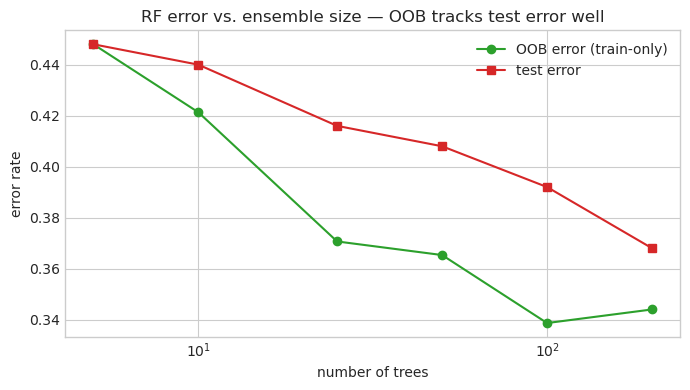

In [8]:
n_list = [5, 10, 25, 50, 100, 200]
oob_curve, test_curve = [], []

for n in n_list:
    m = RandomForestClassifier(
        n_estimators=n, max_features='sqrt',
        oob_score=True, random_state=0,
    ).fit(X_train, y_train)
    oob_curve.append(1 - m.oob_score_)
    test_curve.append(1 - accuracy_score(y_test, m.predict(X_test)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_list, oob_curve, 'o-', label='OOB error (train-only)', color='#2ca02c')
ax.plot(n_list, test_curve, 's-', label='test error', color='#d62728')
ax.set_xscale('log')
ax.set_xlabel('number of trees')
ax.set_ylabel('error rate')
ax.set_title('RF error vs. ensemble size — OOB tracks test error well')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Feature Importance — What Is the Model Actually Using?

Biotech PMs and biologists *will* ask this. Two ways to get it, and they don't always agree.

### Impurity-based importance (Gini importance)

For each feature $k$, sum the Gini reduction across all nodes that split on $k$, then average over all trees (PML Eq. 18.57–18.58):

$$R_k = \frac{1}{M} \sum_{m=1}^M \sum_{j \in \text{nodes}(T_m)} G_j \cdot \mathbb{1}[v_j = k]$$

This comes "for free" with RF (`rf.feature_importances_`), but it has two known failure modes:

- **Biased toward high-cardinality features** — continuous genes can look artificially important vs. binary mutations purely because they offer more split candidates.
- **Splits importance across correlated features** — if you have two highly-correlated genes, the forest uses them interchangeably and each gets half the credit.

### Permutation importance (more robust)

Shuffle feature $k$ in the test set, measure the drop in accuracy. Repeat with fresh shuffles to get a confidence interval. If shuffling $k$ barely hurts, the model wasn't relying on $k$. This respects the model you actually fit and doesn't care about feature cardinality.

In practice: **look at both**, and if they disagree, suspect feature correlation.

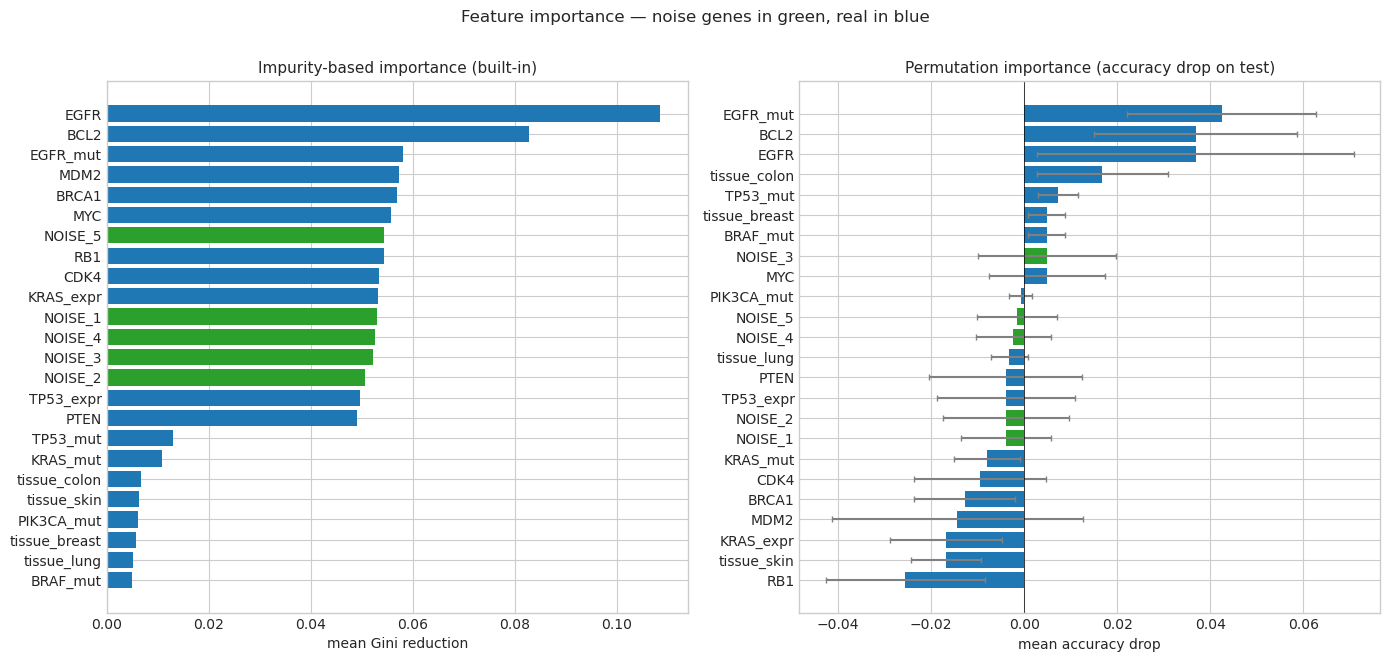

In [9]:
# 1. Impurity-based (built-in)
imp_gini = pd.Series(rf.feature_importances_, index=feature_names).sort_values()

# 2. Permutation importance (on the test set)
perm = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=0,
)
imp_perm = pd.Series(perm.importances_mean, index=feature_names)
imp_perm_std = pd.Series(perm.importances_std, index=feature_names)
order = imp_perm.sort_values().index
imp_perm = imp_perm.loc[order]
imp_perm_std = imp_perm_std.loc[order]

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharey=False)

colors_g = ['#2ca02c' if f.startswith('NOISE') else '#1f77b4' for f in imp_gini.index]
axes[0].barh(imp_gini.index, imp_gini.values, color=colors_g)
axes[0].set_title('Impurity-based importance (built-in)', fontsize=11)
axes[0].set_xlabel('mean Gini reduction')

colors_p = ['#2ca02c' if f.startswith('NOISE') else '#1f77b4' for f in imp_perm.index]
axes[1].barh(imp_perm.index, imp_perm.values, xerr=imp_perm_std.values,
             color=colors_p, ecolor='gray', capsize=2)
axes[1].set_title('Permutation importance (accuracy drop on test)', fontsize=11)
axes[1].set_xlabel('mean accuracy drop')
axes[1].axvline(0, color='black', lw=0.5)

plt.suptitle('Feature importance — noise genes in green, real in blue', y=1.01)
plt.tight_layout()
plt.show()

Notice that the **NOISE_** genes (green) cluster near the bottom on both — the RF correctly ignores them. The top features are the ones we baked into the true biology: `EGFR_mut`, `EGFR`, `KRAS_mut`, `BCL2`, `TP53_mut`. Exactly what we'd hope for.

The impurity method tends to give *continuous* genes slightly inflated scores; permutation is flatter and arguably more honest, but noisier (hence the error bars).

> **Biotech gotcha — correlated features.** If you have two isoforms of the same gene, or a gene and its pathway activity score, the forest will split importance between them. Neither looks dominant, even if together they explain most of the signal. Fix: cluster correlated features and report importance per cluster, or use SHAP values (not covered here, but see the `shap` library).

## 6. Gradient Boosting — Usually the Accuracy Winner

Where RF reduces **variance** by averaging independent trees, **boosting** (PML §18.5) reduces **bias** by fitting trees *sequentially*, each one correcting the previous ensemble's errors.

The additive model (Eq. 18.15):

$$f_m(\mathbf{x}) = f_{m-1}(\mathbf{x}) + \nu \cdot F_m(\mathbf{x}; \theta_m)$$

At step $m$, we fit a small tree $F_m$ to the *negative gradient of the loss* evaluated at the current predictions (Eq. 18.41):

$$F_m = \arg\min_F \sum_{i=1}^N \left( -g_{im} - F(\mathbf{x}_i) \right)^2, \quad g_{im} = \left[ \frac{\partial \ell(y_i, f(\mathbf{x}_i))}{\partial f(\mathbf{x}_i)} \right]_{f = f_{m-1}}$$

For squared error loss, the gradient is just the residual $y_i - f_{m-1}(\mathbf{x}_i)$ — so boosting literally fits the residuals. The shrinkage $\nu$ (learning rate, usually 0.01–0.1) is critical for regularization.

In practice the go-to implementations are **XGBoost**, **LightGBM**, and **CatBoost**. Scikit-learn's `HistGradientBoostingClassifier` is binary-identical to LightGBM in spirit, ships in sklearn, and is usually fast enough. We'll use it here for portability.

In [10]:
gbdt = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,
    max_depth=4,
    early_stopping=True,    # stops when validation loss plateaus
    validation_fraction=0.15,
    random_state=0,
).fit(X_train, y_train)

print(f'Gradient boosting test acc: {accuracy_score(y_test, gbdt.predict(X_test)):.3f}')
print(f'Gradient boosting test AUC: {roc_auc_score(y_test, gbdt.predict_proba(X_test)[:, 1]):.3f}')
print(f'Actual trees used:          {gbdt.n_iter_} (early-stopped from max_iter=500)')

Gradient boosting test acc: 0.680
Gradient boosting test AUC: 0.750
Actual trees used:          42 (early-stopped from max_iter=500)


### Side-by-side: single tree vs. bag vs. RF vs. GBDT

A typical story on tabular biotech data: single tree weakest, bagging and RF much better, gradient boosting usually a hair better still — and it gets there with many fewer trees.

In [11]:
models = {
    'Single tree (depth 5)':   DecisionTreeClassifier(max_depth=5, random_state=0),
    'Bagging (50 trees)':      BaggingClassifier(DecisionTreeClassifier(random_state=0),
                                                 n_estimators=50, random_state=0),
    'Random Forest (200)':     RandomForestClassifier(n_estimators=200, max_features='sqrt',
                                                      random_state=0),
    'Gradient Boosting':       HistGradientBoostingClassifier(
                                   max_iter=500, learning_rate=0.05, max_depth=4,
                                   early_stopping=True, random_state=0),
}

rows = []
for name, m in models.items():
    m.fit(X_train, y_train)
    rows.append((
        name,
        accuracy_score(y_test, m.predict(X_test)),
        roc_auc_score(y_test, m.predict_proba(X_test)[:, 1]),
    ))

df_cmp = pd.DataFrame(rows, columns=['model', 'test_acc', 'test_AUC'])
print(df_cmp.to_string(index=False))

                model  test_acc  test_AUC
Single tree (depth 5)     0.512  0.514081
   Bagging (50 trees)     0.648  0.702765
  Random Forest (200)     0.632  0.703661
    Gradient Boosting     0.720  0.742704


## 7. Hyperparameter Tuning — The Three Knobs That Matter

Most of the accuracy gap between "okay" and "great" boosted-tree models comes from three settings. Everything else is second-order.

| Hyperparameter | What it does | Typical range |
|---|---|---|
| **`learning_rate`** (ν) | Shrinkage — how much each tree contributes. Smaller = more trees needed, better generalization. | 0.01 – 0.1 |
| **`n_estimators` / `max_iter`** | Total number of boosting rounds. Use early stopping. | 100 – 2000+ |
| **`max_depth`** | Depth of each weak learner. Boosting wants shallow trees (3–8); deeper for complex interactions. | 3 – 8 |

Secondary: `min_samples_leaf` / `min_child_samples` (leaf-size floor, combats overfitting on small datasets), `l2_regularization`, `max_features` / `colsample_bytree` (feature subsampling per tree, adds randomization).

**The golden rule**: smaller `learning_rate` + more trees + early stopping almost always beats aggressive learning rates.

### Learning curves: spot overfitting visually

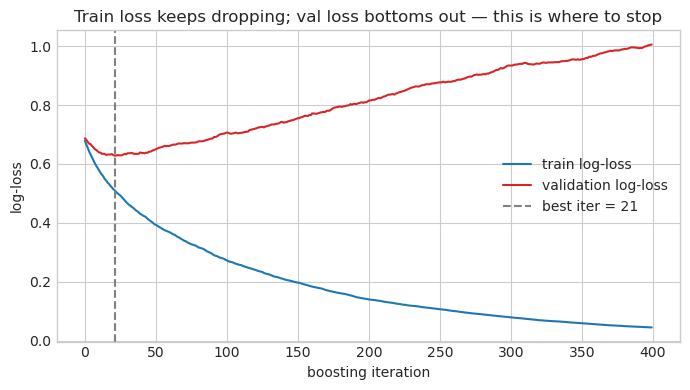

In [12]:
# Fit without early stopping so we can see the full loss trajectory
gbdt_full = HistGradientBoostingClassifier(
    max_iter=400, learning_rate=0.05, max_depth=4,
    early_stopping=False, random_state=0,
)
# scikit-learn exposes the staged validation loss via fitting on a held-out slice
X_tr, X_va, y_tr, y_va = train_test_split(X_train, y_train, test_size=0.2,
                                          stratify=y_train, random_state=1)

gbdt_full.fit(X_tr, y_tr)

# staged_decision_function gives predictions at each boosting iteration
train_losses, val_losses = [], []
from sklearn.metrics import log_loss
for p_tr, p_va in zip(gbdt_full.staged_predict_proba(X_tr),
                      gbdt_full.staged_predict_proba(X_va)):
    train_losses.append(log_loss(y_tr, p_tr))
    val_losses.append(log_loss(y_va, p_va))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, label='train log-loss', color='#1f77b4')
ax.plot(val_losses,   label='validation log-loss', color='#d62728')
ax.axvline(np.argmin(val_losses), ls='--', color='gray',
           label=f'best iter = {np.argmin(val_losses)}')
ax.set_xlabel('boosting iteration')
ax.set_ylabel('log-loss')
ax.set_title('Train loss keeps dropping; val loss bottoms out — this is where to stop')
ax.legend()
plt.tight_layout()
plt.show()

Validation loss reaches a minimum and then creeps back up — that's your early-stopping point. Let `early_stopping=True` do this automatically in production.

### A quick cross-validated sweep

For real work, use a small grid over `learning_rate` and `max_depth` with k-fold CV. Here's a minimal sweep you can adapt:

In [13]:
results = []
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
for lr in [0.05, 0.1]:
    for depth in [3, 6]:
        m = HistGradientBoostingClassifier(
            max_iter=300, learning_rate=lr, max_depth=depth,
            early_stopping=True, random_state=0,
        )
        scores = cross_val_score(m, X_train, y_train, cv=cv, scoring='roc_auc')
        results.append((lr, depth, scores.mean(), scores.std()))

df_grid = pd.DataFrame(results, columns=['lr', 'depth', 'AUC_mean', 'AUC_std'])
df_grid = df_grid.sort_values('AUC_mean', ascending=False).reset_index(drop=True)
print(df_grid.to_string(index=False))
print(f'\nBest config: lr={df_grid.iloc[0].lr}, depth={int(df_grid.iloc[0].depth)}')

  lr  depth  AUC_mean  AUC_std
0.05      3  0.731353 0.038930
0.10      3  0.728196 0.039492
0.10      6  0.711342 0.037370
0.05      6  0.698754 0.024319

Best config: lr=0.05, depth=3


With real datasets (especially if you're considering XGBoost/LightGBM/CatBoost), **Optuna** or **scikit-optimize** are worth the 20 lines of extra code — they find better configurations much faster than a grid.

## 8. Partial Dependence Plots — What Did the Model Learn?

After fitting, you want to interrogate the model: *"How does predicted sensitivity change as EGFR expression varies, averaging out everything else?"* That's exactly what a **partial dependence plot (PDP)** shows (PML Eq. 18.59):

$$\bar f_k(x_k) = \frac{1}{N} \sum_{n=1}^N f(\mathbf{x}_{n, -k}, x_k)$$

For each value of feature $k$, replace everyone's $k$-th feature with it, predict, and average. The resulting curve is the model's best guess at the marginal effect of $k$.

**Two-feature PDPs** (Eq. 18.60) reveal interactions — the kind of thing biologists look for when arguing about combination therapies.

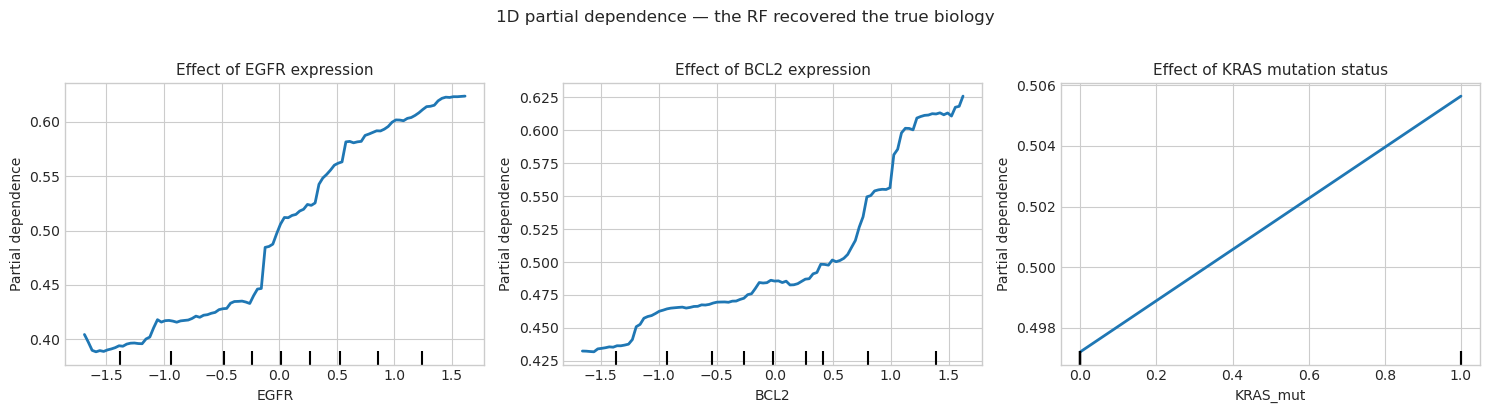

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1D PDPs for the most important continuous features
PartialDependenceDisplay.from_estimator(
    rf, X_train,
    features=[feature_names.index('EGFR')],
    feature_names=feature_names,
    ax=axes[0], line_kw={'color': '#1f77b4', 'lw': 2},
)
axes[0].set_title('Effect of EGFR expression', fontsize=11)

PartialDependenceDisplay.from_estimator(
    rf, X_train,
    features=[feature_names.index('BCL2')],
    feature_names=feature_names,
    ax=axes[1], line_kw={'color': '#1f77b4', 'lw': 2},
)
axes[1].set_title('Effect of BCL2 expression', fontsize=11)

PartialDependenceDisplay.from_estimator(
    rf, X_train,
    features=[feature_names.index('KRAS_mut')],
    feature_names=feature_names,
    ax=axes[2], line_kw={'color': '#1f77b4', 'lw': 2},
)
axes[2].set_title('Effect of KRAS mutation status', fontsize=11)

plt.suptitle('1D partial dependence — the RF recovered the true biology', y=1.02)
plt.tight_layout()
plt.show()

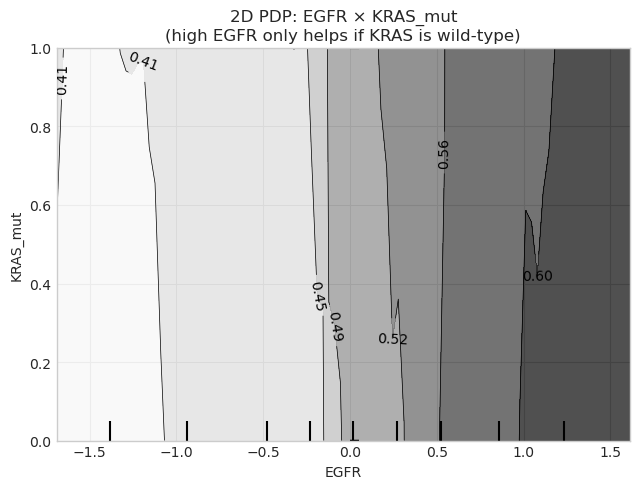

In [15]:
# 2D PDP — the EGFR x KRAS_mut interaction we engineered
fig, ax = plt.subplots(figsize=(6.5, 5))
PartialDependenceDisplay.from_estimator(
    rf, X_train,
    features=[(feature_names.index('EGFR'), feature_names.index('KRAS_mut'))],
    feature_names=feature_names,
    ax=ax,
)
ax.set_title('2D PDP: EGFR × KRAS_mut\n(high EGFR only helps if KRAS is wild-type)')
plt.tight_layout()
plt.show()

The 1D plots show exactly what we put into the data: EGFR expression monotonically raises sensitivity, BCL2 does too (its own effect averaged over TP53 status), and KRAS mutation *lowers* it. The 2D PDP shows the interaction — EGFR's effect is muted when KRAS is mutated. If this were a real experiment you'd now tell the team: *"this drug won't work in KRAS-mutant tumors even if EGFR is high"*, which is indeed a well-known resistance mechanism.

> **PDP caveat.** PDPs assume features are independent. If EGFR expression is strongly correlated with some other feature, the PDP may extrapolate into feature combinations that never occur in nature (a breast-tissue sample with lung-tissue expression levels, say). **ICE plots** (individual conditional expectation) and **ALE plots** (accumulated local effects) handle this more carefully. The `sklearn.inspection` and `PyALE` libraries support them.

## 9. Practical Cheat Sheet

### Which model to reach for first

| Situation | Pick |
|---|---|
| Small data (N < 200), mostly linear signal | **Logistic / Ridge regression** (with interpretable coefficients) |
| Tabular biotech data, N = 200 – 5 000 | **Gradient boosting** (XGBoost / LightGBM / HistGBM) |
| Want a no-fuss baseline, accuracy not paramount | **Random Forest** (little tuning needed) |
| Very high-dim sparse data (genomics with $D \gg N$) | **Lasso / Elastic Net** first, trees second |
| Need calibrated probabilities | **GBDT with log-loss** or RF with **isotonic calibration** |
| Need to deploy with minimal tuning/risk | **Random Forest** — harder to shoot yourself in the foot than with boosting |

### The pitfalls that bite biotech practitioners

1. **Data leakage via preprocessing.** Normalize / impute / select features *inside* the CV loop, not before. A common bug: z-scoring using the full dataset's mean/std before splitting leaks test statistics into training.
2. **Leakage via sample grouping.** If you have multiple replicates per cell line / patient, split by *group*, not by row (`sklearn.model_selection.GroupKFold`). Otherwise one replicate ends up in train, another in test, and your AUC is fantasy.
3. **Class imbalance.** Most drugs hit a minority of cell lines. Use `class_weight='balanced'`, stratified splits, and report **AUPRC** or balanced accuracy — not raw accuracy.
4. **Distribution shift.** Cell lines ≠ tumors, mouse ≠ human. The model will predict confidently on inputs outside the training distribution. Always hold out a *structurally different* test set (e.g., a tumor type the model never saw) for the final sanity check.
5. **Correlated features split importance.** If two isoforms, paralogs, or a gene and its pathway score are in the feature set, both will look moderately important even if the signal is from their shared component. Cluster first, or use SHAP for consistent attribution.
6. **Overinterpreting PDPs.** They assume feature independence. When features are correlated, prefer **ALE plots** or **ICE plots**.
7. **Extrapolation.** Trees extrapolate as constants past the training range — a cell line with EGFR expression 3× higher than anything in training will simply get the leaf value of the most extreme training sample. Linear models extrapolate smoothly (though often wrongly too); tree ensembles just flatline.
8. **Don't trust `feature_importances_` blindly.** It's biased toward high-cardinality features and doesn't reflect the held-out predictive value. Use permutation importance on the test set for final reports, or SHAP for per-sample attributions.

### What's *not* covered here but worth knowing

- **SHAP values** — per-sample, theoretically grounded feature attributions. Standard for model explanation in publications (`shap` library).
- **Monotonic constraints** — tell the model "higher drug concentration should never decrease predicted effect" (supported in XGBoost / LightGBM / CatBoost). Biologists love these.
- **Quantile regression forests** — get prediction intervals, useful for IC50 regression and dose-response work.
- **Survival forests** — `scikit-survival` / `xgboost-survival` for time-to-event data (patient outcomes, clinical trial analyses).

---

## Appendix — Biology Quick Start

If you're new to cancer biology, here's just enough context to follow every claim in this notebook. It's aimed at someone comfortable with basic biology (genes, proteins, DNA) but unfamiliar with oncology.

### What is a cancer cell line?

A **cancer cell line** is a population of cancer cells originally taken from a patient's tumor and now grown indefinitely in flasks in a lab. Think of each cell line as a *frozen snapshot* of one patient's cancer, reproducible across labs. Hundreds of them have been systematically profiled (DNA sequenced, RNA measured, drugs screened) and deposited in public databases:

- **CCLE** (Cancer Cell Line Encyclopedia) — Broad Institute, ~1000 lines.
- **GDSC** (Genomics of Drug Sensitivity in Cancer) — Sanger Institute, similar panel with heavy drug screening.
- **TCGA** (The Cancer Genome Atlas) — actual patient tumors, not cell lines.

When someone in ML-for-biology says *"predict drug response from multi-omics"*, they almost always mean: train on CCLE/GDSC, test on held-out cell lines or (ambitiously) on TCGA patients.

### Two kinds of features: expression vs. mutation

These are the two feature types we use in the notebook, and they are **independent**:

| Feature type | Measured from | What it tells you | Values |
|---|---|---|---|
| **Gene expression** | RNA (mRNA) | How much of the gene's protein the cell is currently *producing* | Continuous (TPM, FPKM, log-counts) |
| **Mutation status** | DNA | Whether the gene's DNA sequence is *altered* (and may code a broken or hyperactive protein) | Usually binary (0 = wild-type, 1 = mutated) |

A single gene can be:

- **Highly expressed + wild-type**: the normal protein, just lots of it.
- **Mutated + low expression**: a broken/altered protein, but not much of it around.
- **Mutated + highly expressed**: the worst case — a hyperactive mutant, everywhere.
- **Low expression + wild-type**: silent, probably irrelevant.

In a real pharmacogenomics dataset, you'd also have *copy number* (how many DNA copies of the gene exist), *methylation* (epigenetic silencing), and *proteomics* (actual protein abundance). We kept it to expression + mutations for simplicity.

### The biology we baked into the simulated data

The drug in our story is a **targeted therapy**: a small molecule designed to inhibit one specific protein. Real-world examples include erlotinib and gefitinib, which both inhibit **EGFR**. Here's each gene in the simulation and why it matters:

#### EGFR — the drug's target

- **Epidermal Growth Factor Receptor** — a protein sticking out of the cell membrane. When activated, it tells the cell *"grow and divide"*.
- **High EGFR expression** means the cell has lots of these "grow!" receptors on its surface. Blocking them with a drug should stop proliferation → **sensitive**.
- **EGFR mutation** (our binary `EGFR_mut` feature): certain mutations lock the receptor permanently in its "on" state. The cell becomes *addicted* to that signal. An EGFR-targeting drug hits the addiction directly → **extremely sensitive**. This is called **oncogene addiction** and is the foundation of precision oncology for lung cancer.

#### KRAS — why the drug stops working

- **KRAS** is a small signalling switch *downstream* of EGFR. Think of EGFR as a doorbell and KRAS as the wire running from the doorbell to an alarm inside the house. When EGFR rings, KRAS passes the signal along.
- **KRAS mutation** locks that wire *permanently on*. The cell no longer needs the doorbell (EGFR) — it's getting a continuous grow-signal regardless of what's happening on the cell surface.
- Implication: **inhibiting EGFR is pointless when KRAS is mutated**. You've disconnected the doorbell, but the alarm is already ringing.
- This is why, in our simulated biology, `high EGFR × (1 - KRAS_mut)` appears — EGFR expression only predicts sensitivity *when KRAS is wild-type*. And this is real biology: KRAS-mutant colon cancer patients are explicitly excluded from cetuximab (an anti-EGFR antibody) therapy because it doesn't work.

#### TP53 and BCL2 — the death machinery

- **TP53** (the p53 protein) is famously called *"the guardian of the genome"*. When a cell detects DNA damage or stress, p53 triggers either repair or programmed cell death (**apoptosis**). It's the most frequently mutated gene in human cancer — losing TP53 is a classic way cancer cells escape self-destruction.
- **BCL2** is a *brake* on apoptosis: it keeps cells alive. High BCL2 = harder to kill.
- **The interaction we baked in**: BCL2 level matters *only when TP53 is wild-type*, because TP53 is the one actively deciding whether to trigger death. If TP53 is broken (mutated), the apoptosis pathway is already disabled upstream and BCL2's brake is irrelevant.
- The biological term for *"only matters in the right genetic context"* relationships like this is **synthetic lethality**, and finding these is a huge area of modern cancer drug discovery.

#### Tissue of origin

- Lung cancer, breast cancer, colon cancer, and melanoma (skin) look different under a microscope, grow in different microenvironments, carry different co-occurring mutations, and respond differently to drugs — even when they share the same driver gene.
- In our simulation, lung cell lines are slightly more sensitive overall. This matches reality for EGFR inhibitors, which were originally developed *for* lung cancer (specifically non-small-cell lung cancer, NSCLC).

#### The noise genes and noise mutations

- `NOISE_1` … `NOISE_5` and `BRAF_mut`, `PIK3CA_mut` are included as **distractor features**. They have no effect on the true sensitivity label. We include them because real pharmacogenomics datasets contain *thousands* of genes, most of which are irrelevant to any given drug. A useful model has to find the signal genes among the noise — exactly what the feature importance plots in Section 5 demonstrate.

### How drug sensitivity is actually measured in the lab

When a biologist says *"this cell line is sensitive to drug X"*, here's what happened physically:

1. They plated the cells in 96-well or 384-well plates (a grid of tiny wells, each holding maybe 10 000 cells in a drop of growth medium).
2. They added increasing concentrations of the drug across the wells (e.g. 10 nM, 100 nM, 1 µM, 10 µM).
3. After 2–4 days, they measured how many cells survived in each well, typically with a fluorescent viability dye.
4. They fit a sigmoid curve: viability vs. log-concentration.
5. They read off the **IC50** — the concentration at which 50% of cells are dead.

**Low IC50 = sensitive** (a tiny amount of drug kills them). **High IC50 = resistant**.

In published datasets you'll also see **AUC** (area under the dose-response curve, *not* ROC-AUC!) as a sensitivity metric, especially in GDSC. A common modeling setup is:

- **Regression** target: predict IC50 or AUC directly from the omics features.
- **Classification** target: binarize — "sensitive" if IC50 < threshold, else "resistant". We chose this setup in the notebook because it makes importance plots and PDPs easier to interpret.

### Why tree models for this specifically

Pharmacogenomics has two properties that make trees shine:

1. **Threshold effects**: a cell line with EGFR expression 2 is *qualitatively* different from one with expression 0.5, not just quantitatively. Trees naturally carve the input space at exactly these biologically meaningful thresholds.
2. **Gene × gene interactions**: the effect of one gene usually depends on the status of others (the KRAS example above). Linear models need you to manually write `EGFR * (1 - KRAS_mut)` interaction terms; trees discover these automatically from the data.

These are the same reasons tree ensembles dominate in drug discovery, clinical outcome prediction, and biomarker panel design.

### Glossary

| Term | One-line definition |
|---|---|
| **Oncogene** | A gene whose mutation *gains* a cancer-driving function (e.g., KRAS, EGFR, MYC). |
| **Tumor suppressor** | A gene whose mutation *loses* a protective function (e.g., TP53, PTEN, RB1). |
| **Wild-type** | The normal, unmutated form of a gene. |
| **Pathway** | A chain of proteins passing signals to one another (e.g., EGFR → KRAS → MAPK → cell division). |
| **Targeted therapy** | A drug designed to block one specific protein (contrast with chemotherapy, which is non-specific). |
| **Precision oncology** | Choosing a drug based on a patient's *specific* molecular profile. |
| **Biomarker** | A measurable feature (gene expression, mutation, protein level) that predicts something clinical (diagnosis, prognosis, drug response). |
| **Apoptosis** | Programmed cell death — the cell's built-in self-destruct program. |
| **Synthetic lethal** | A combination of two genetic changes that is lethal only when both are present. A major framework for new cancer drugs. |
| **Oncogene addiction** | A cancer's dependence on a single mutated oncogene, which makes drugs targeting it devastatingly effective. |
| **IC50** | Drug concentration that kills 50% of cells — the standard sensitivity metric. |

### Where to go next

If you want a deeper dive into cancer biology as a quantitative scientist:

- **Hanahan & Weinberg, *"Hallmarks of Cancer: The Next Generation"* (2011)** — ~30 pages, cited over 80 000 times. The de facto conceptual overview of cancer biology for non-biologists.
- **cBioPortal** (cbioportal.org) — a free interactive explorer for TCGA data. Pick a gene, see mutations, expression, and survival curves across 30+ cancer types.
- **DepMap** (depmap.org) — the Broad Institute's interactive portal for CCLE cell line data. Lets you plot drug response vs. any gene feature for any drug.
- **The EGFR and KRAS Wikipedia pages** — surprisingly good, and they give you the history of why targeting these genes changed oncology.